# Processing 3.1 - Lung Annotation

## Introduction

Here the annotation for the visium data from lung is performed.

In [1]:
setwd(here::here())

## Libraries

In [2]:
library(here)
library(glue)
library(tidyverse)
library(patchwork)
library(colorBlindness)
library(HDF5Array)
library(Seurat)
library(SpatialExperiment)
library(scran)
library(scuttle)
library(igraph)
library(ggspavis)
library(pheatmap)
library(lisi)
library(scater)
library(dittoSeq)
library(svglite)

here() starts at /home/groups/singlecell/cvicente/SP-COVID/visium/0-processing

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SparseArray

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:lubridate’:

    as.difftime


The following object is 

## Load data

In [3]:
annot_df <- read_csv("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant/data/visium/metadata_visium_lung_covid_so.csv")
annot_df

New names:
• `` -> `...1`
Rows: 24181 Columns: 65
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): ...1, orig.ident, experiment, diseasePhase, barcodes, disease_phas...
dbl (58): nCount_Spatial, nFeature_Spatial, percent.mt, nCount_SCT, nFeature...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


...1,orig.ident,nCount_Spatial,nFeature_Spatial,percent.mt,experiment,diseasePhase,barcodes,nCount_SCT,nFeature_SCT,⋯,REACTOME_ALTERNATIVE_COMPLEMENT_ACTIVATION,REACTOME_COLLAGEN_BIOSYNTHESIS_AND_MODIFYING_ENZYMES,REACTOME_COMPLEMENT_CASCADE,REACTOME_LECTIN_PATHWAY_OF_COMPLEMENT_ACTIVATION,REACTOME_SCAVENGING_OF_HEME_FROM_PLASMA,REACTOME_TGF_BETA_RECEPTOR_SIGNALING_IN_EMT_EPITHELIAL_TO_MESENCHYMAL_TRANSITION,REACTOME_VEGFR2_MEDIATED_VASCULAR_PERMEABILITY,GOBP_VIRAL_GENE_EXPRESSION,integrated_snn_res.0.35,newID
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AAACAAGTATCTCCCA-1_1,SeuratProject,4480,1797,6.607143,A329,chronic,AAACAAGTATCTCCCA-1,2851,1665,⋯,0.429867012,0.1722605785,0.035258011,0.126028011,0.08976933,0.46463799,0.192570497,0.235224465,5,stoma_2
AAACAATCTACTAGCA-1_1,SeuratProject,3107,1514,6.533634,A329,chronic,AAACAATCTACTAGCA-1,2694,1506,⋯,-0.031574385,0.1759381170,0.045889628,0.199317898,-0.18974401,-0.26667780,-0.268393739,0.050423969,2,endothelia_1
AAACAGAGCGACTCCT-1_1,SeuratProject,1816,957,4.900881,A329,chronic,AAACAGAGCGACTCCT-1,2031,955,⋯,-0.427944455,-0.1732125225,0.038898070,0.055792663,-0.14594472,-0.27102490,0.077518057,0.047079727,0,epithelia_1
AAACCCGAACGAAATC-1_1,SeuratProject,3793,1776,8.331136,A329,chronic,AAACCCGAACGAAATC-1,2787,1741,⋯,-0.441744818,-0.0277057290,0.058576608,0.335658950,0.34870760,-0.32452765,0.048664993,-0.055223035,1,macrophages
AAACCGGGTAGGTACC-1_1,SeuratProject,1415,794,8.127208,A329,chronic,AAACCGGGTAGGTACC-1,1889,795,⋯,0.139646954,-0.0461374122,0.041806646,0.128876530,-0.01348492,-0.29108843,0.180153347,0.256762377,5,stoma_2
AAACGAAGAACATACC-1_1,SeuratProject,7085,2768,7.579393,A329,chronic,AAACGAAGAACATACC-1,2185,1099,⋯,0.372685621,0.0119906759,0.050864302,0.028551655,-0.07782372,0.37635845,0.072065843,0.239042460,1,macrophages
AAACGAGACGGTTGAT-1_1,SeuratProject,1562,878,6.786172,A329,chronic,AAACGAGACGGTTGAT-1,1931,875,⋯,-0.423539995,0.3037954890,-0.080872043,0.040760577,0.07544445,-0.22989465,0.023735728,0.207765014,5,stoma_2
AAACGCCCGAGATCGG-1_1,SeuratProject,5689,1991,3.410090,A329,chronic,AAACGCCCGAGATCGG-1,2710,1459,⋯,0.405098303,0.1426049592,-0.015444791,0.155458776,-0.10937018,0.35830127,0.136694180,0.185455633,5,stoma_2
AAACGTGTTCGCCCTA-1_1,SeuratProject,2706,1382,5.875831,A329,chronic,AAACGTGTTCGCCCTA-1,2553,1379,⋯,0.133399974,0.0197795248,-0.157947251,0.353646372,-0.33662168,-0.32653401,0.109718534,-0.070806175,0,epithelia_1


In [4]:
spe <- loadHDF5SummarizedExperiment(
  dir = "out/2-processed_lung_spe" %>%
    glue::glue() %>%
    here::here()
)

spe

class: SpatialExperiment 
dim: 30450 33211 
metadata(0):
assays(2): counts logcounts
rownames(30450): ENSG00000238009 ENSG00000241860 ... SCoV2_ORF10
  SCoV2_UTR3
rowData names(5): symbol subsets_mito subsets_ribo subsets_SCoV2
  gene_name
colnames(33211): AAACAAGTATCTCCCA-1 AAACACCAATAACTGC-1 ...
  TTGTTTCCATACAACT-1 TTGTTTGTGTAAATTC-1
colData names(39): in_tissue array_row ... Leiden_res_0.75
  lisi_study_id
reducedDimNames(3): PCA UMAP HARMONY
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : pxl_col_in_fullres pxl_row_in_fullres
imgData names(4): sample_id image_id data scaleFactor

## Transfering previous annotation

We will annotate the lung samples using the previous annotation from "Distinct tissue niches direct lung immunopathology via CCL18 and CCL21 in severe COVID-19".

In [5]:
lookup <- annot_df %>%
    mutate(sample_id = case_when(experiment == "S208_4" ~ "S208",
                                 experiment == "O448n" ~ "O448",
                                 TRUE ~ experiment),
           barcodes = sub("_.*$", "", annot_df$`...1`)) %>%
    select(sample_id, barcodes, newID)

spe$annotation <- left_join(
    data.frame(sample_id = sub("-lung$", "", spe$sample_id),
               barcodes = rownames(colData(spe))),
    lookup, by = c("sample_id", "barcodes")) %>%
    mutate(newID = case_when(newID == "stroma_1" ~ "Vascular",
                             newID == "endothelia_2" ~ "Fibrovascular",
                             newID == "endothelia_1" ~ "Fibroblasts",
                             newID == "stoma_2" ~ "Smooth muscle/Myofibroblasts",
                             newID == "epithelia_1" ~ "Alveolar epithelia",
                             newID == "epithelia_2" ~ "Secretory epithelia",
                             newID == "macrophages" ~ "Macrophages",
                             newID == "plasma cells" ~ "Plasma cells",
                             newID == "hemoglobin" ~ "Erythrocytes",
                             TRUE ~ newID),
           newID = replace_na(newID, "Unassigned")) %>%
    pull(newID)

In [6]:
palette <- c("Alveolar epithelia" = "#FF6DB6", "Secretory epithelia" = "#FFB6DB",
             "Vascular" = "#004949", "Fibrovascular" = "#007A7A", "Fibroblasts" = "#00B4B4",
             "Smooth muscle/Myofibroblasts" = "#80DADA", "Macrophages" = "#490092", "Plasma cells" = "#B66DFF", 
             "Erythrocytes" = "#924900", "Unassigned" = "#920000")

ct <- names(palette)  

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Ad

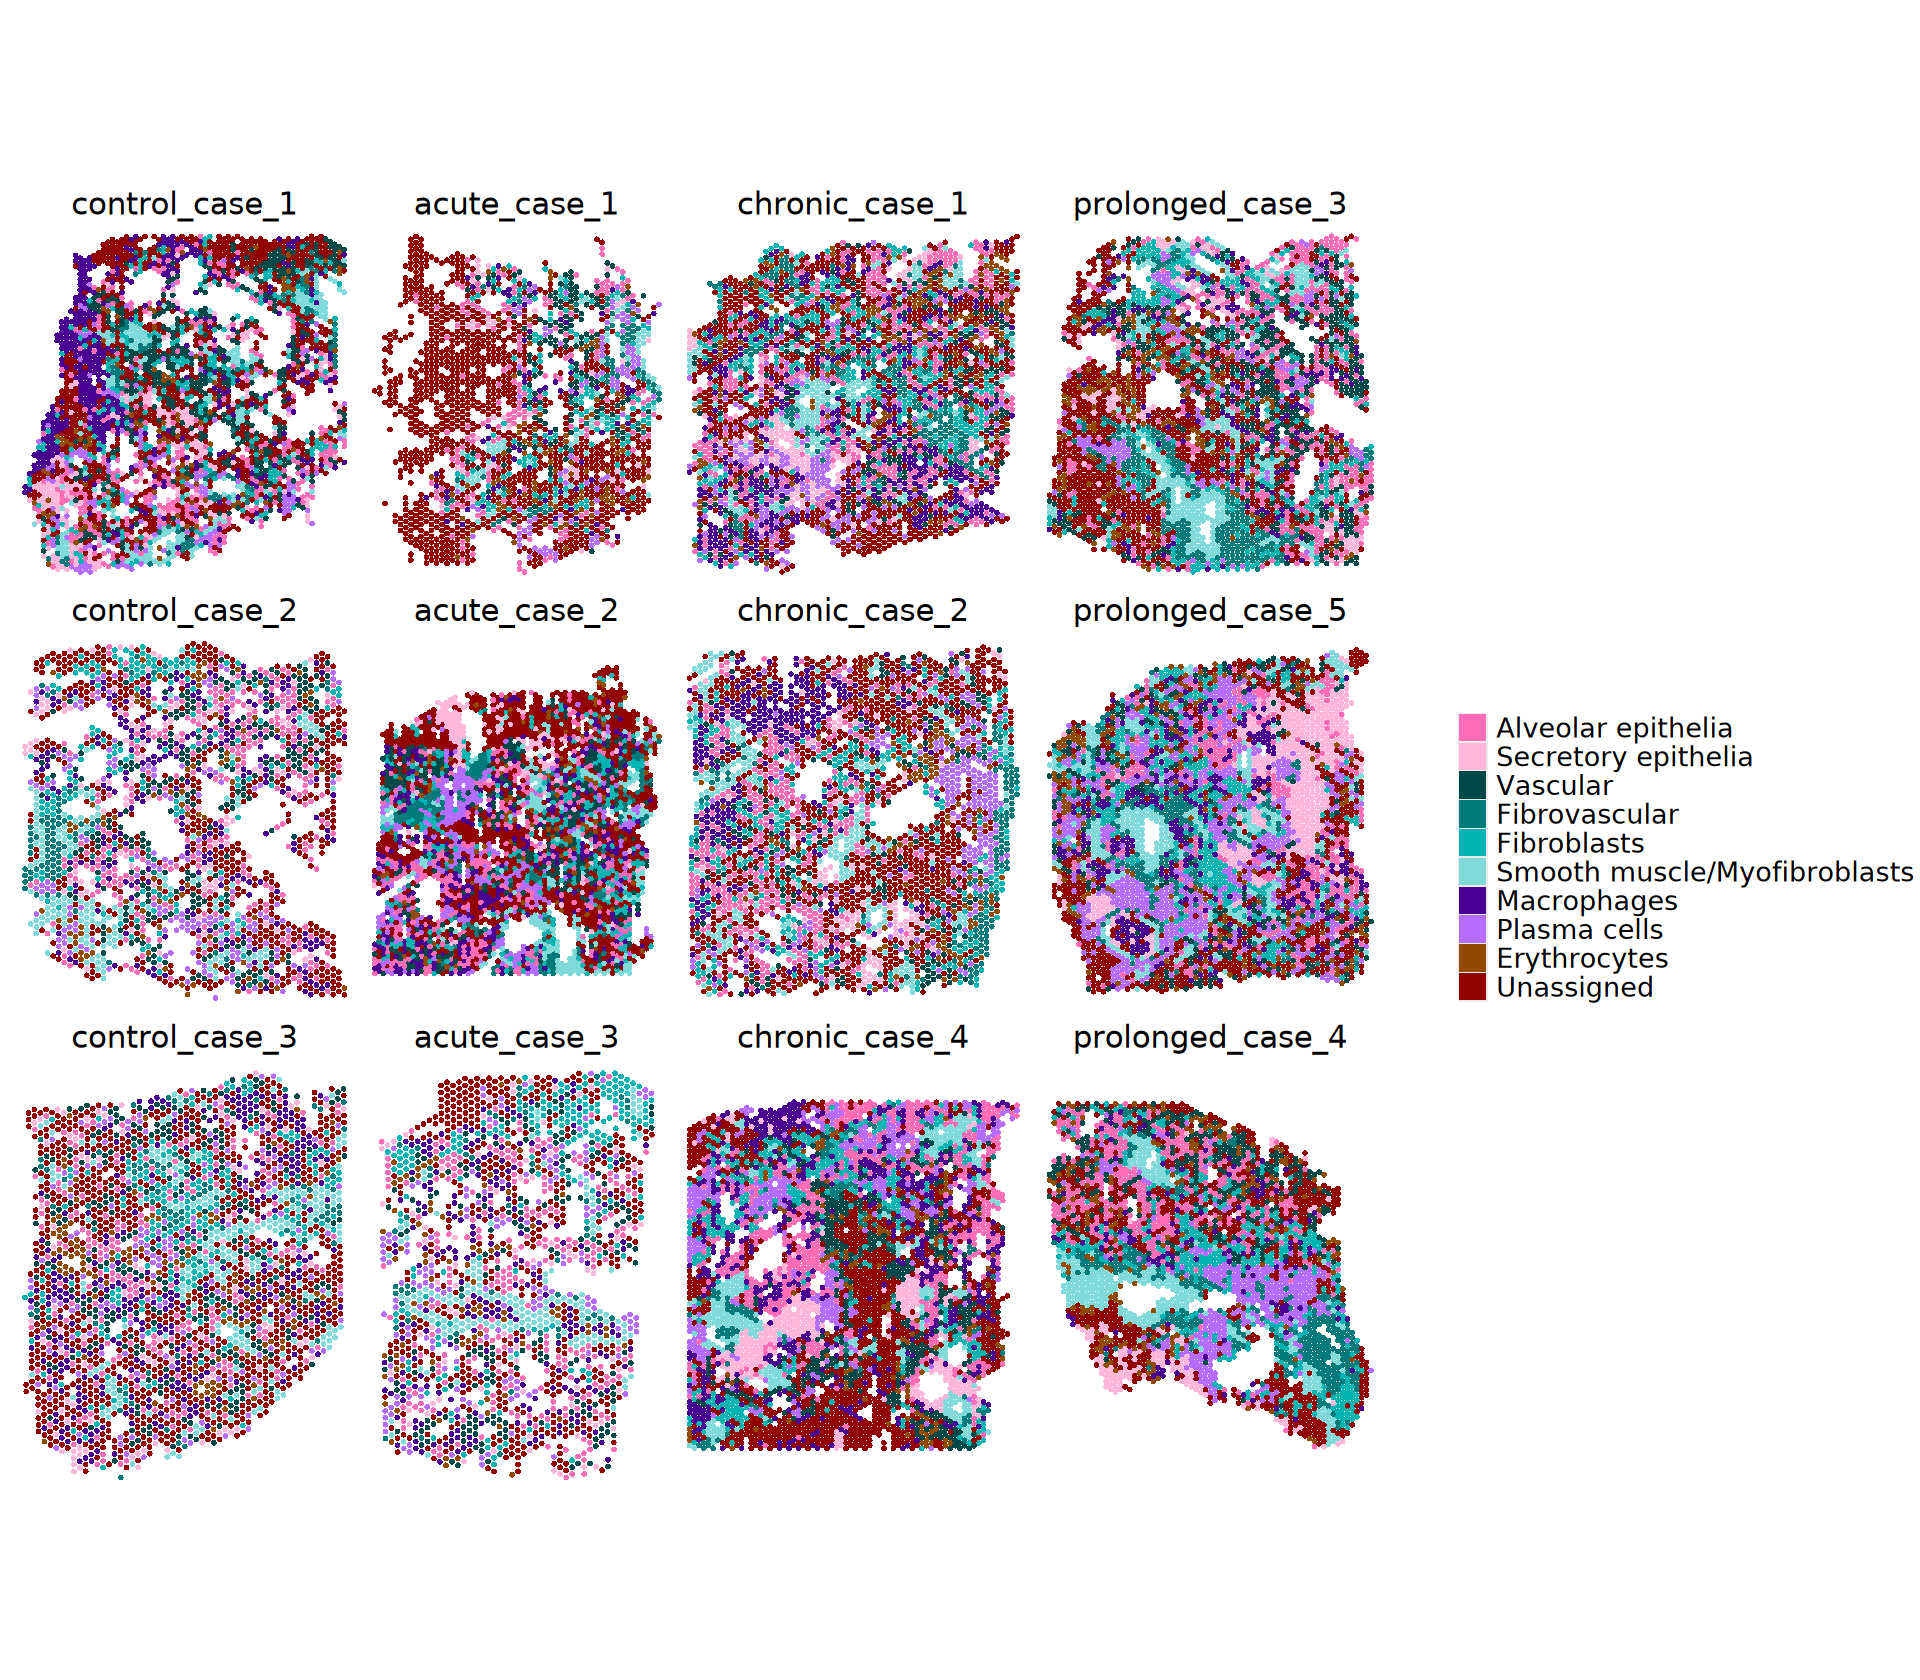

In [7]:
options(repr.plot.width = 16, repr.plot.height = 14, warn = -1)

plots <- lapply(unique(spe$study_id), function(id){
    sub <- spe[, spe$study_id == id]
    plotCoords(sub, annotate = "annotation", point_size = 1) +
        scale_color_manual(values = palette, drop = FALSE) + 
        coord_fixed() + 
        ggtitle(id) +
        theme_void() +
        theme(legend.position = "none",
              plot.title = element_text(hjust = 0.5, size = 18)) 
})


legend_plot <- ggplot(
    data.frame(ct = factor(ct, levels = ct), x = 1, y = seq_along(ct)),
    aes(x, y, fill = ct)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = palette, breaks = ct, limits = ct, name = "") +
    theme(legend.position = "right",
          legend.background = element_blank(),
          legend.text = element_text(size = 16),
          legend.title = element_text(size = 16),
          legend.key = element_rect(color = NA)) +
    guides(fill = guide_legend(ncol = 1))
legend <- cowplot::get_legend(legend_plot)

p <- cowplot::plot_grid(
    wrap_plots(plots, ncol = 4, byrow = FALSE),
    legend,
    ncol = 2,
    rel_widths = c(8, 3))

ggsave("out/plots/spatial_domains_lung.svg", plot = p, device = svglite, width = 16, height = 14)
print(p)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for co

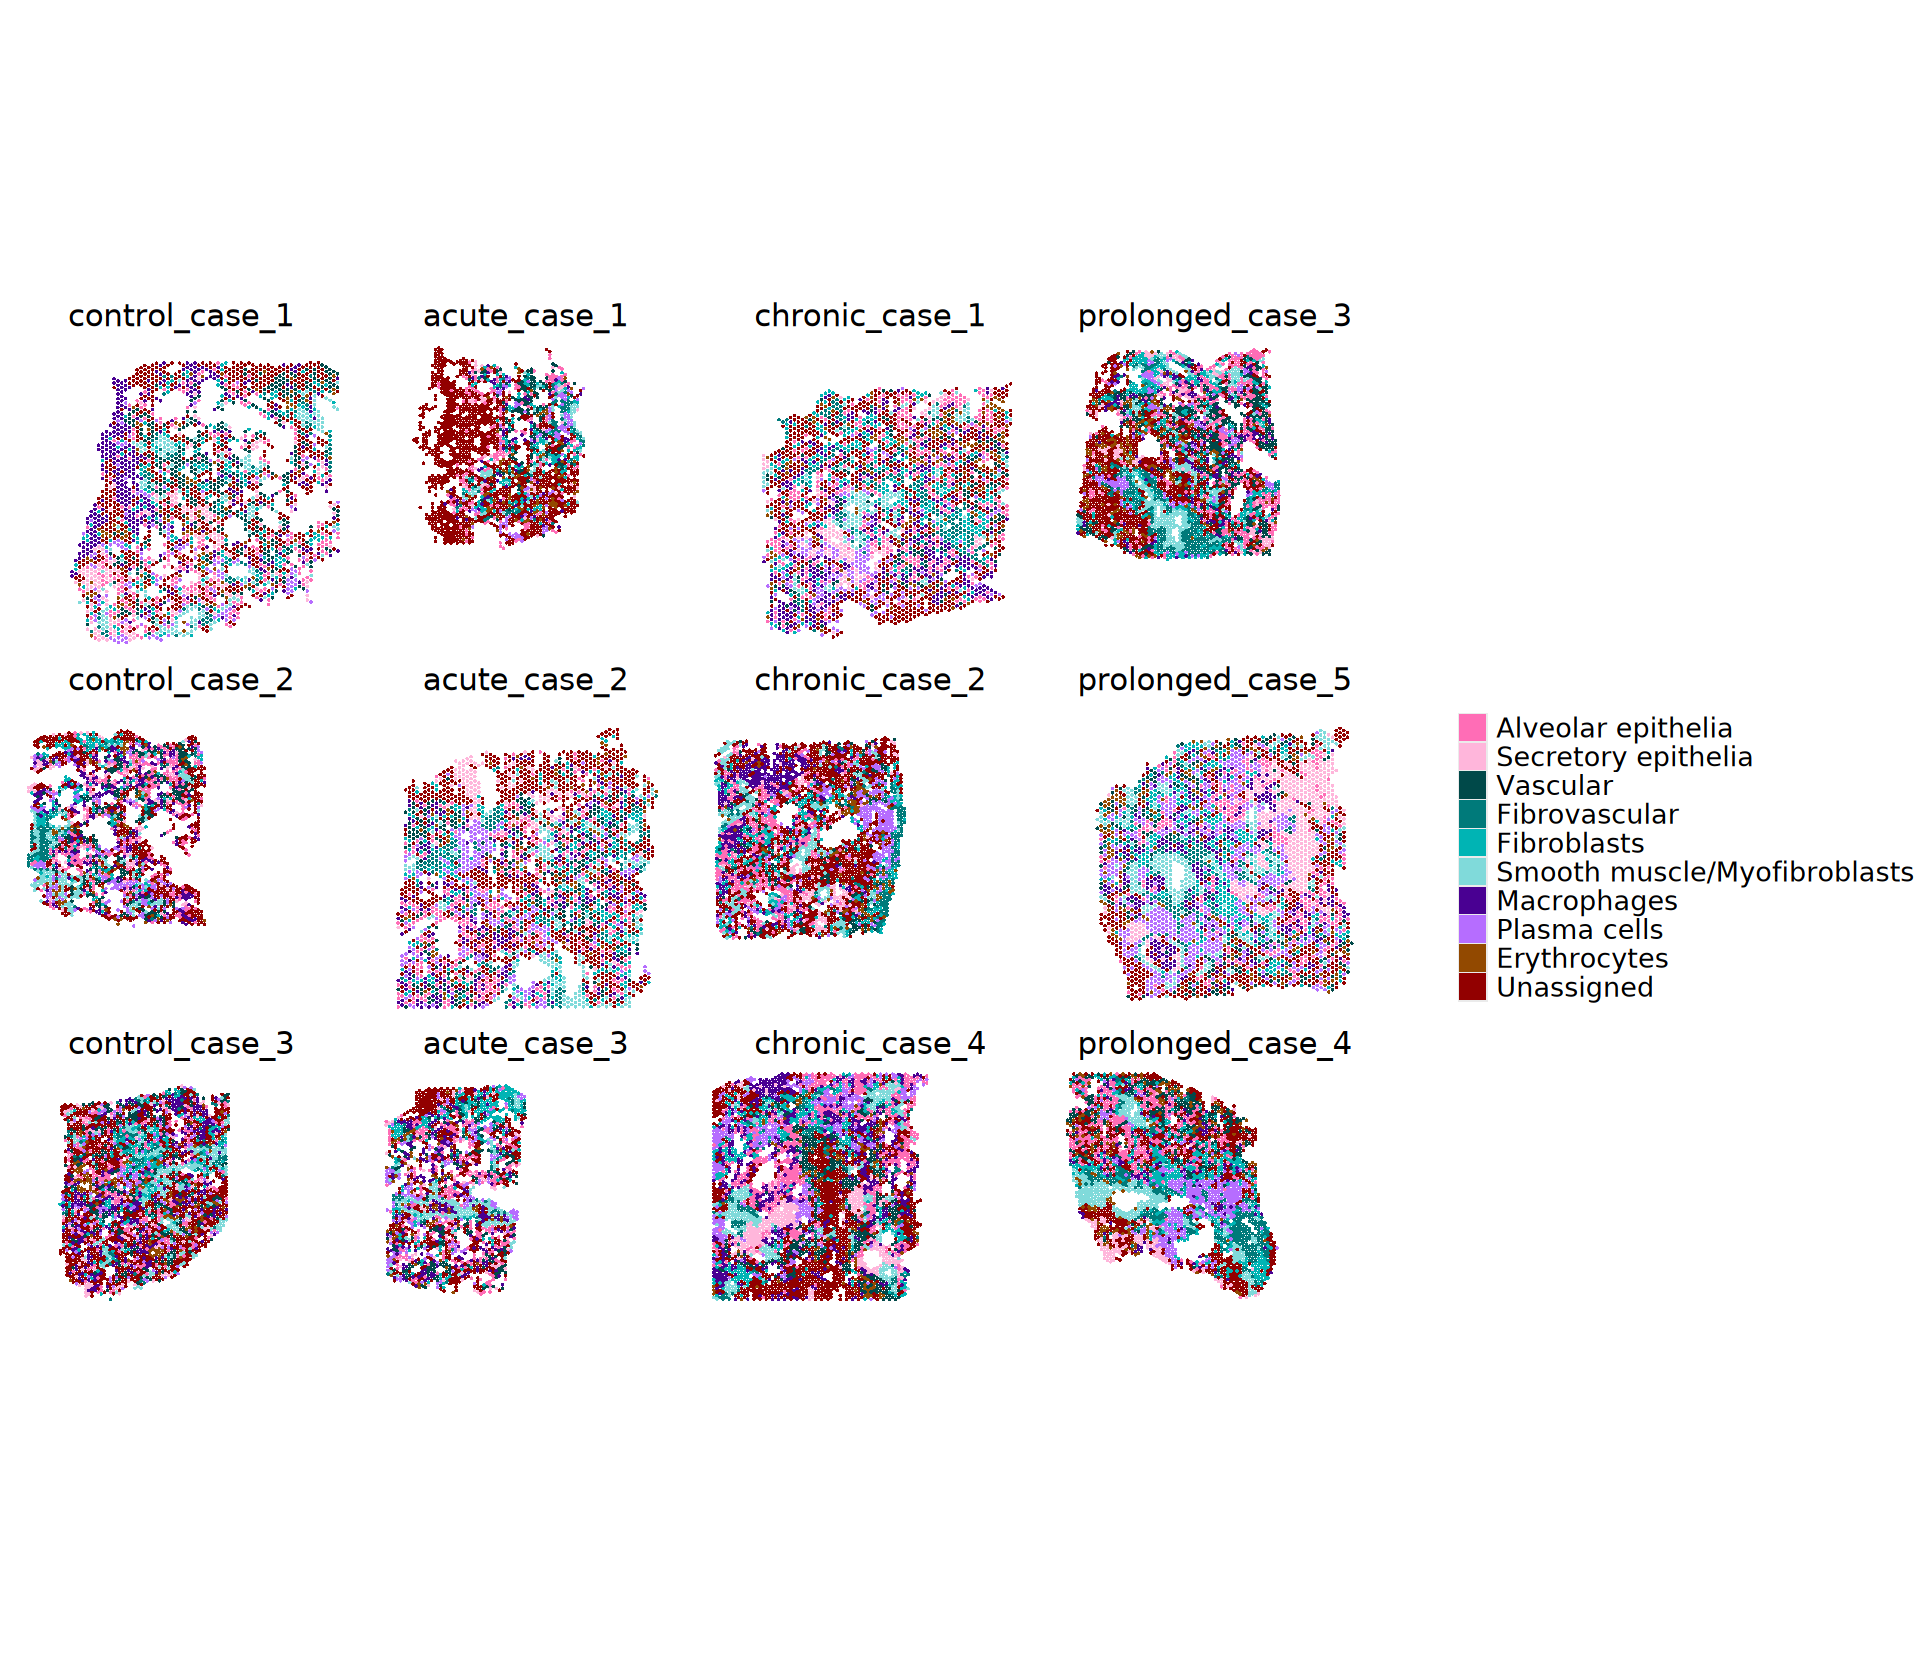

In [8]:
options(repr.plot.width = 16, repr.plot.height = 14, warn = -1)

global_x_min <- min(spatialCoords(spe)[, 1])
global_x_max <- max(spatialCoords(spe)[, 1])
global_y_min <- min(spatialCoords(spe)[, 2])
global_y_max <- max(spatialCoords(spe)[, 2])

plots <- lapply(unique(spe$study_id), function(id){
    sub <- spe[, spe$study_id == id]
    plotCoords(sub, annotate = "annotation", point_size = 0.4) +
        scale_color_manual(values = palette, drop = FALSE) + 
        coord_fixed() + 
        ggplot2::xlim(global_x_min, global_x_max) + 
        ggplot2::ylim(global_y_max, global_y_min) + 
        ggtitle(id) +
        theme_void() +
        theme(legend.position = "none",
              plot.title = element_text(hjust = 0.5, size = 18)) 
})


legend_plot <- ggplot(
    data.frame(ct = factor(ct, levels = ct), x = 1, y = seq_along(ct)),
    aes(x, y, fill = ct)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = palette, breaks = ct, limits = ct, name = "") +
    theme(legend.position = "right",
          legend.background = element_blank(),
          legend.text = element_text(size = 16),
          legend.title = element_text(size = 16),
          legend.key = element_rect(color = NA)) +
    guides(fill = guide_legend(ncol = 1))
legend <- cowplot::get_legend(legend_plot)

p <- cowplot::plot_grid(
    wrap_plots(plots, ncol = 4, byrow = FALSE),
    legend,
    ncol = 2,
    rel_widths = c(8, 3))

ggsave("out/plots/spatial_domains_lung_coords.svg", plot = p, device = svglite, width = 16, height = 14)
print(p)

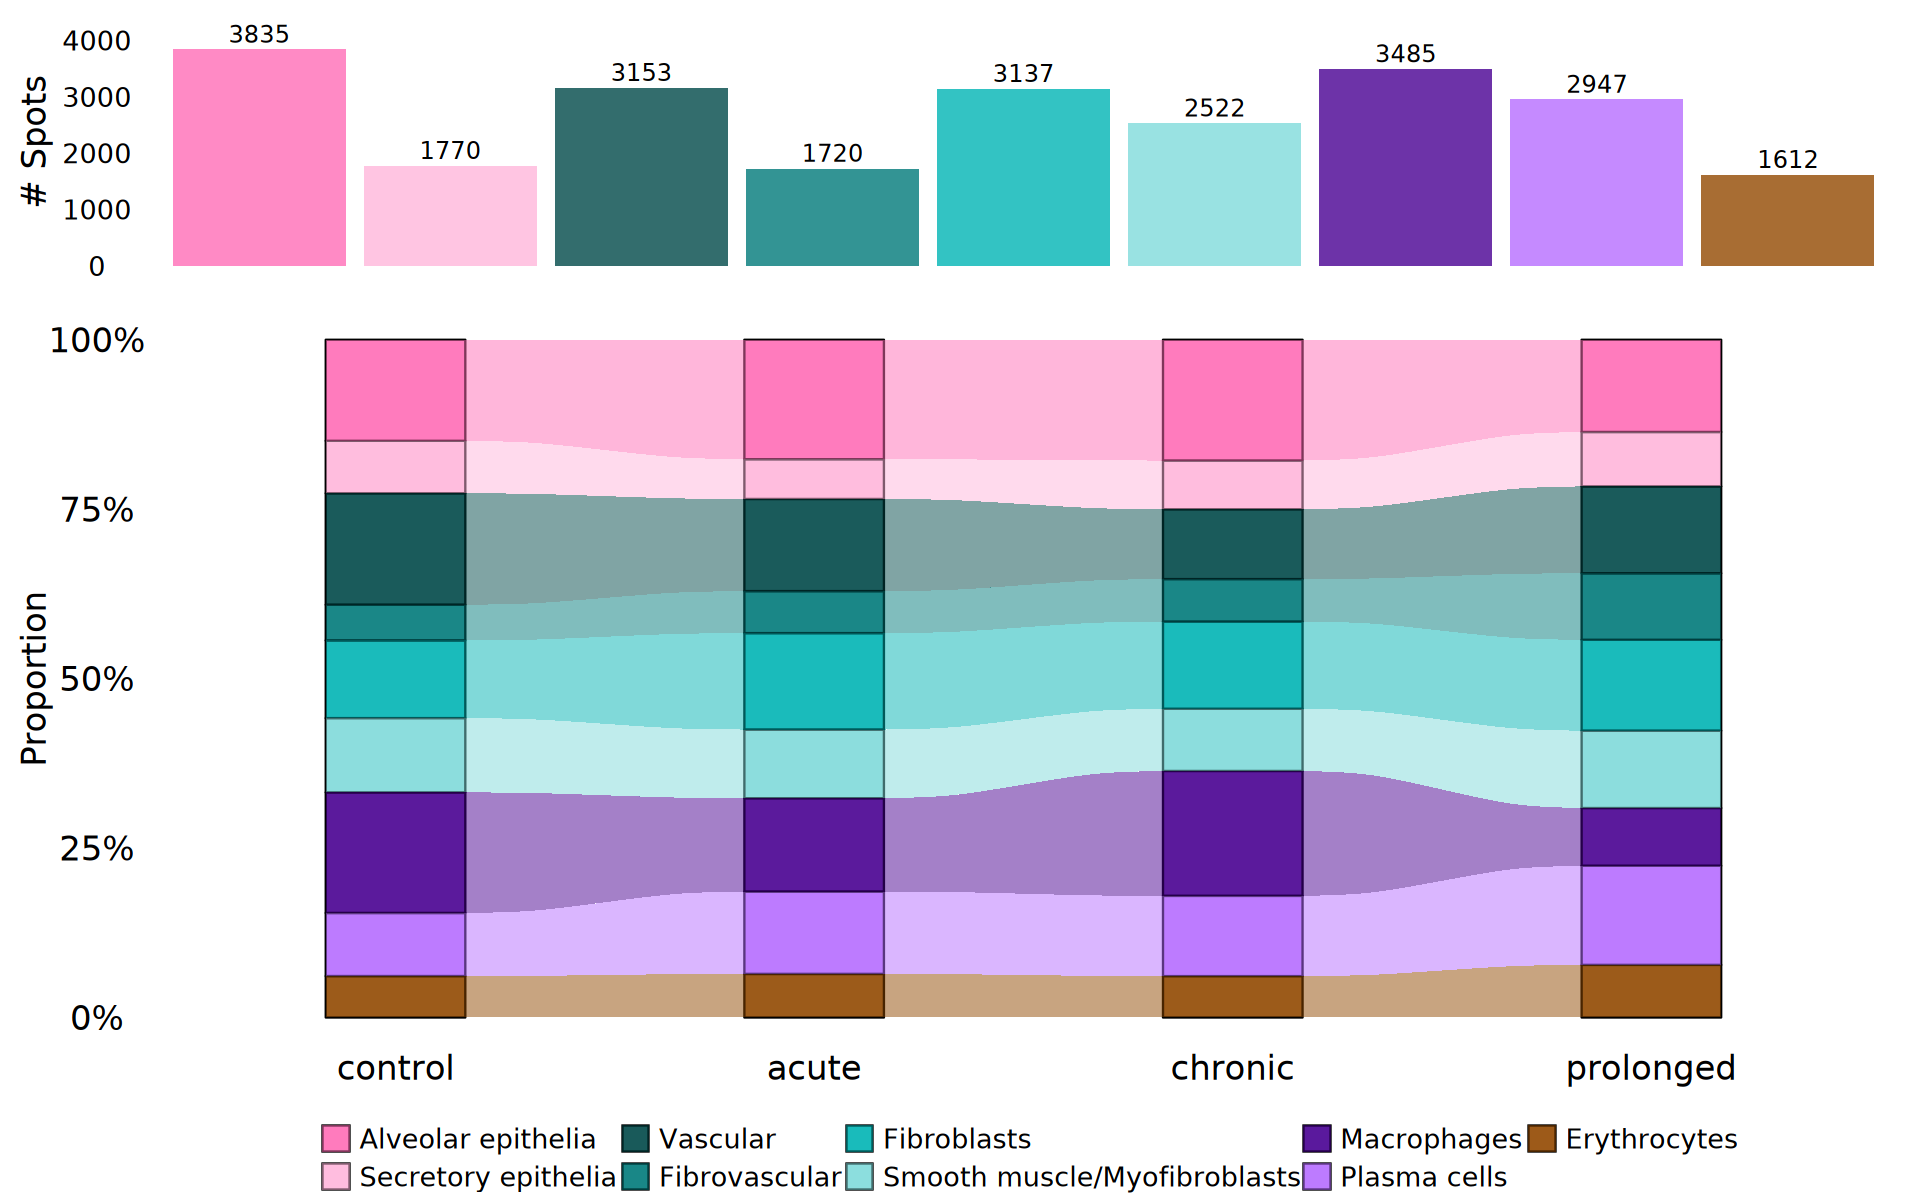

In [9]:
options(repr.plot.width = 16, repr.plot.height = 10, warn = -1)

p_top <- as.data.frame(colData(spe)) %>%
    filter(annotation != "Unassigned") %>%
    dplyr::count(annotation) %>%
    dplyr::arrange(match(annotation, ct)) %>%
    mutate(annotation = factor(annotation, levels = ct)) %>%
    ggplot(aes(x = annotation, y = n, fill = annotation)) +
    geom_bar(stat = "identity", alpha = 0.8) +
    geom_text(aes(label = n), vjust = -0.4, size = 5, color = "black") +
    labs(x = "", y = "# Spots") +
    scale_fill_manual(values = palette, guide = "none") +
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
    theme_void() +
    theme(axis.text.y = element_text(color = "black", size = 16),
          axis.title = element_text(color = "black", size = 20),
          axis.title.y = element_text(angle = 90),
          plot.margin = margin(5, 5, 5, 5))

p_bottom <- as.data.frame(colData(spe)) %>%
    filter(annotation != "Unassigned") %>%
    mutate(disease_group = factor(disease_group,
                                  levels = c("control", "acute", "chronic", "prolonged"))) %>%
    dplyr::count(disease_group, annotation) %>%
    dplyr::group_by(disease_group) %>%
    dplyr::mutate(prop = n / sum(n)) %>%
    dplyr::ungroup() %>%
    mutate(annotation = factor(annotation, levels = ct)) %>%
    ggplot(aes(x = disease_group, y = prop, fill = annotation,
               alluvium = annotation, stratum = annotation)) +
    ggalluvial::geom_stratum(alpha = 0.8) +
    ggalluvial::geom_alluvium(alpha = 0.5) +
    labs(x = "", y = "Proportion") +
    scale_y_continuous(labels = scales::percent_format()) +
    scale_fill_manual(values = palette, name = "") +
    theme_void() +
    theme(axis.text = element_text(color = "black", size = 20),
          axis.title = element_text(color = "black", size = 20),
          axis.title.y = element_text(angle = 90),
          legend.text = element_text(size = 16),
          legend.title = element_text(size = 16),
          legend.position = "bottom")

p <- p_top / p_bottom + patchwork::plot_layout(heights = c(1, 3))

ggsave("out/plots/barplot_stage_lung_n.svg", plot = p, device = svglite, width = 20, height = 10)
print(p)

## Differential expression

In [10]:
mgs <- findMarkers(spe, groups = spe$annotation, direction = "up")
top <- lapply(mgs, \(df) rownames(df)[df$Top <= 2])

In [11]:
spe_dot <- spe
top <- rowData(spe_dot)[unique(unlist(top)), ]$gene_name

colnames(spe_dot) <- paste(colData(spe)$cond_tissue, colnames(spe), sep = "_")

annotation_order <- c("Alveolar epithelia", "Secretory epithelia", "Vascular", "Fibrovascular", 
                      "Fibroblasts", "Smooth muscle/Myofibroblasts", "Macrophages", "Plasma cells",
                      "Erythrocytes", "Unassigned")
spe_dot$annotation <- factor(spe_dot$annotation, levels = rev(annotation_order))
gene_order <- lapply(annotation_order, function(ann) {
    df <- mgs[[ann]]
    rownames(df)[df$Top <= 2]}) %>%
    unlist() %>%
    unique()

gene_order <- rowData(spe_dot)[gene_order, ]$gene_name
gene_order <- gene_order[!is.na(gene_order)]

rowData(spe_dot)$ensembl <- rownames(spe)
rownames(spe_dot) <- rowData(spe)$gene_name

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


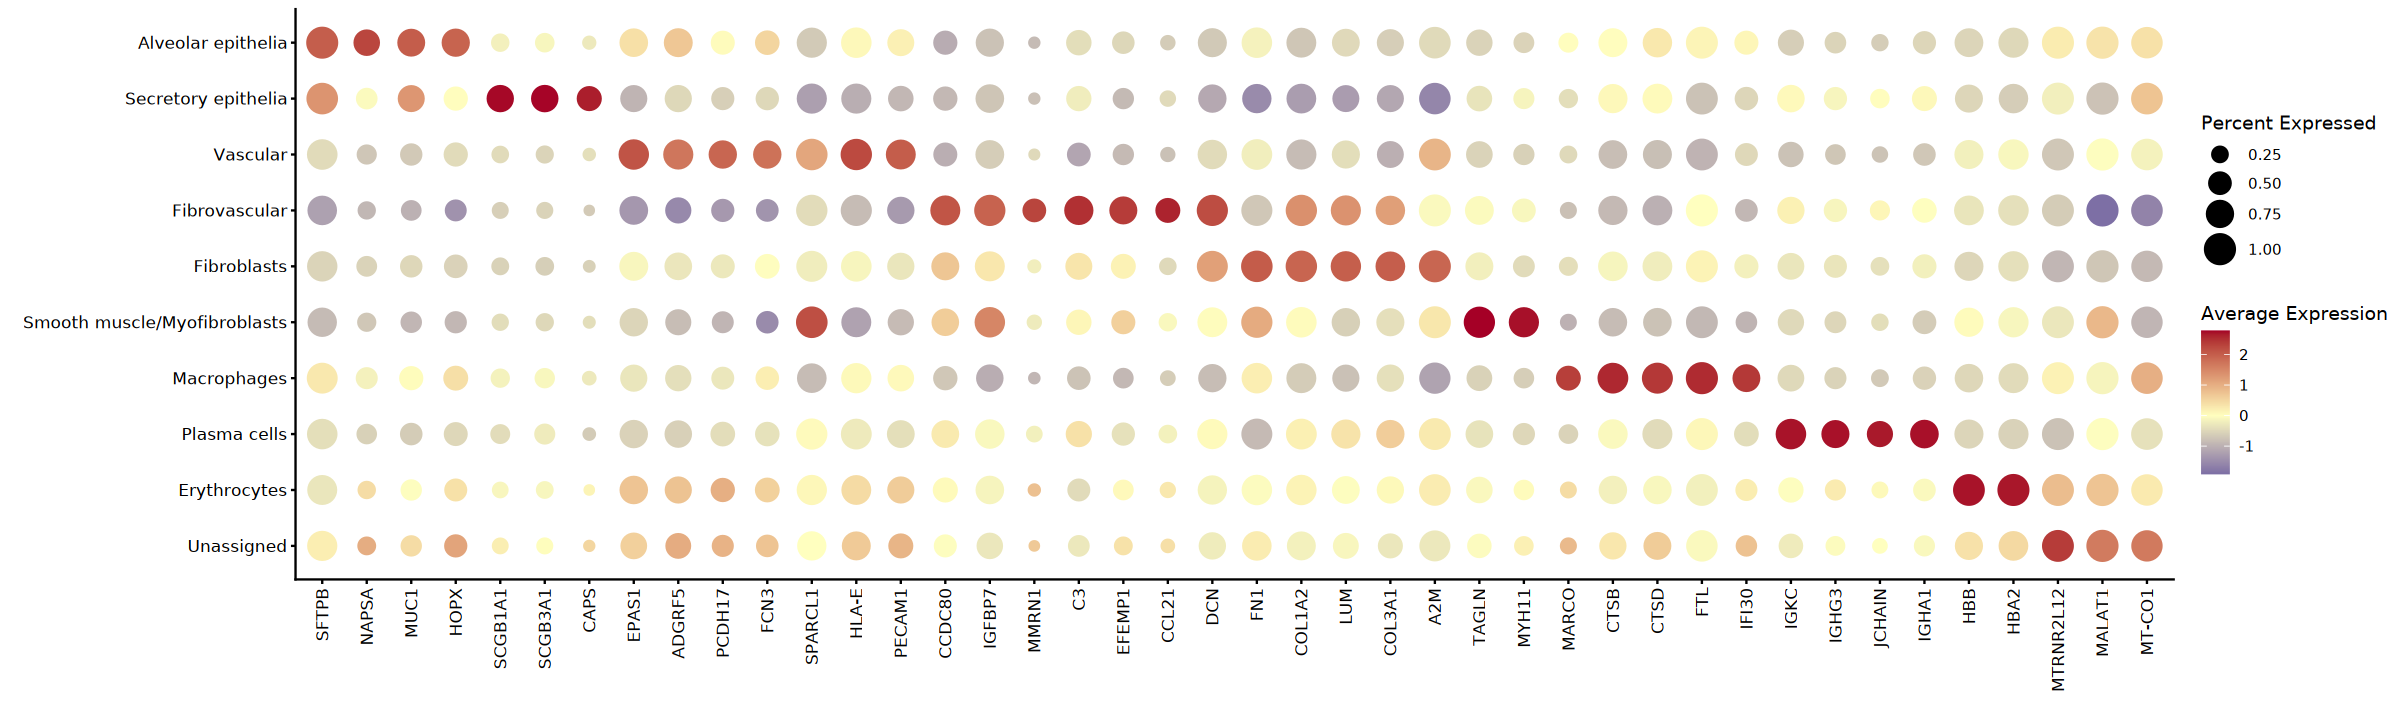

In [12]:
options(repr.plot.width = 20, repr.plot.height = 6, warn = -1)

p <- dittoDotPlot(spe_dot, vars = gene_order, group.by = "annotation", size = 8, legend.size.title = "Percent Expressed") +  
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 10),
          axis.text.y = element_text(size = 10),
          plot.title = element_text(hjust = 0.5, size = 14, face = "bold")) +
    labs(y = "", x = "") +
    scale_color_gradient2(low = "#313695", mid = "#FFFFBF", high = "#A50026", midpoint = 0, name = "Average Expression") 
ggsave("out/plots/dotplot_annot_lung.svg", plot = p, device = svglite, width = 20, height = 6)
print(p)

## Save data

In [13]:
remove <- grep("^Leiden_res_", names(colData(spe)), value = TRUE)
colData(spe) <- colData(spe)[, !names(colData(spe)) %in% remove]

saveHDF5SummarizedExperiment(spe, replace = TRUE, dir = "out/3-annot_lung_spe" %>%
                               glue::glue() %>%
                               here::here())

## Session information

In [14]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] svglite_2.2.2               dittoSeq_1.22.0            
 [3] scater_1.38.0               lisi_1.0                   
 [5] pheatmap_1.0.13             ggspavis_1.16.0            
 [7] igraph_2.